# Testing Python Control library

In [19]:
import control as ct
import numpy as np
import matplotlib.pyplot as plt

## State Space

<StateSpace>: coupled spring mass
Inputs (1): ['u[0]']
Outputs (2): ['q1', 'q2']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[ 0.   0.   1.   0. ]
     [ 0.   0.   0.   1. ]
     [-4.   2.  -0.1  0. ]
     [ 2.  -4.   0.  -0.1]]

B = [[0.]
     [0.]
     [0.]
     [2.]]

C = [[1. 0. 0. 0.]
     [0. 1. 0. 0.]]

D = [[0.]
     [0.]]


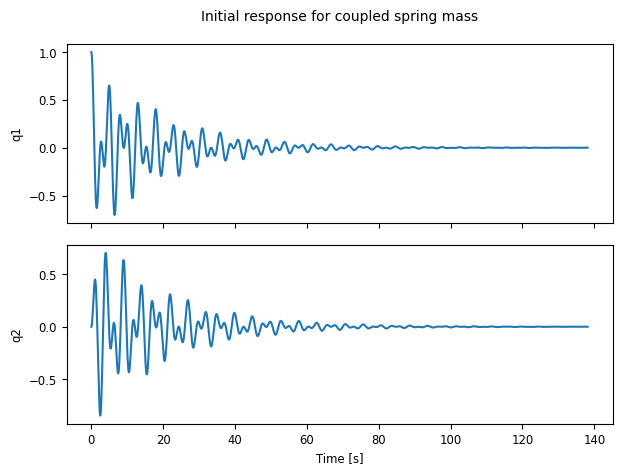

In [ ]:
m,c,k = 1,0.1,2

A = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [-2*k/m, k/m, -c/m, 0],
    [k/m, -2*k/m, 0, -c/m]
])
B = np.array([[0], [0], [0], [k/m]])
C = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
D = 0

sys = ct.ss(A, B, C, D, outputs=['q1', 'q2'], name="coupled spring mass")
print(sys)
x0 = [1,0,0,0]
response = ct.initial_response(sys, X0=x0) # Same as matlab simulate I guess with t,x,y,u
cplt = response.plot()

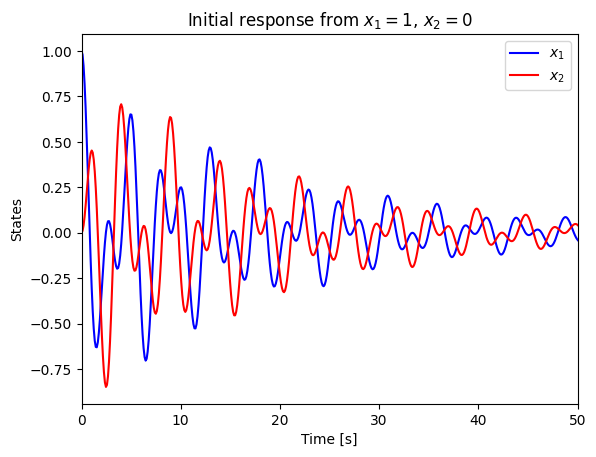

In [26]:
# Plot the outputs of the system on the same graph, in different colors
t = response.time
x = response.states
plt.plot(t, x[0], 'b', t, x[1], 'r')
plt.legend(['$x_1$', '$x_2$'])
plt.xlim(0, 50)
plt.ylabel('States')
plt.xlabel('Time [s]')
plt.title("Initial response from $x_1 = 1$, $x_2 = 0$");

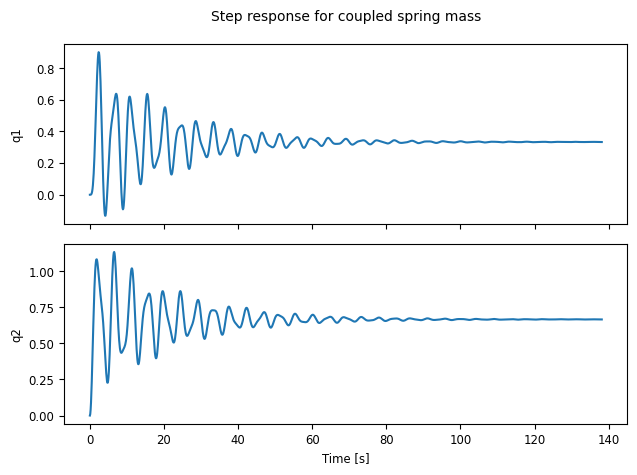

In [32]:
ct.step_response(sys).plot()

In [33]:
step_info = ct.step_info(sys)
print("Input 0, output 0 rise time = ",
      step_info[0][0]['RiseTime'], "seconds\n")
step_info

Input 0, output 0 rise time =  0.615390225299077 seconds



[[{'RiseTime': 0.615390225299077,
   'SettlingTime': 89.02645259326647,
   'SettlingMin': -0.1327284565536944,
   'SettlingMax': 0.9005994876222034,
   'Overshoot': 170.17984628666105,
   'Undershoot': 39.81853696610832,
   'Peak': 0.9005994876222034,
   'PeakTime': 2.3589958636464616,
   'SteadyStateValue': 0.3333333333333333}],
 [{'RiseTime': 0.6153902252990769,
   'SettlingTime': 73.64169696078955,
   'SettlingMin': 0.22760198207822405,
   'SettlingMax': 1.1338933771021502,
   'Overshoot': 70.08400656532254,
   'Undershoot': 0.0,
   'Peak': 1.1338933771021502,
   'PeakTime': 6.564162403190155,
   'SteadyStateValue': 0.6666666666666666}]]

## Transfer Functions

In [36]:
s = ct.tf('s')